# RNN-1 — Multivariate Weather Forecasting (Jena Climate)

**Course project · 25 points · Google Colab**

This notebook builds and compares recurrent forecasters for the Jena Climate dataset. Given the **past 72 hourly readings**, every model jointly predicts the next **12 hours** of:

- `T (degC)` — temperature in °C
- `rh (%)` — relative humidity in percentage points

The primary reported horizons are **1, 3, 6, and 12 hours**, while all 12 horizons are retained for curves and diagnostics.

## Experimental hypothesis (stated before training)

The original contribution uses recurrent LSTM states with **horizon-specific additive temporal attention**. Each future horizon has its own learned query. The hypothesis is that this mechanism will help most at longer horizons by choosing among recent trends and recurring daily-lag evidence rather than compressing the entire history into one vector. This is a hypothesis, **not a promised result**; the evaluation cells determine whether attention actually improves validation/test errors.

## Design choices

The source has about 420k observations sampled every 10 minutes. We resample to **hourly means** because (1) forecast horizons then have an unambiguous meaning in hours, (2) a 72-step input spans exactly three days, and (3) training is practical in a fresh Colab session. All numeric sensor variables are retained. Known `-9999` wind sentinels are converted to missing values before time-aware interpolation. Cyclical hour-of-day and day-of-year features are added without discarding the original sensor columns.

The split is strictly chronological (70/15/15). Inputs may use historical context immediately preceding a validation/test boundary, but every target lies wholly inside its own split. No future values cross a boundary, scaler statistics are fit on training rows only, and only training windows are shuffled.

In [ ]:
# Imports, reproducibility, Colab detection, and configuration
import json
import math
import os
import random
import shutil
import time
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 2026
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception as exc:
    print("Deterministic TensorFlow ops could not be enabled:", exc)

FAST_MODE = False  # Set False for the stronger, slower course-report run.
CFG = {
    "seed": SEED,
    "fast_mode": FAST_MODE,
    "lookback_hours": 72,
    "forecast_hours": 12,
    "sequence_stride": 3 if FAST_MODE else 1,
    "units": 32 if FAST_MODE else 64,
    "epochs": 10 if FAST_MODE else 30,
    "batch_size": 128,
    "learning_rate": 1e-3,
    "dropout": 0.10,
    "patience": 3 if FAST_MODE else 6,
}
LOOKBACK = CFG["lookback_hours"]
HORIZON = CFG["forecast_hours"]
STRIDE = CFG["sequence_stride"]
TARGETS = ["T (degC)", "rh (%)"]
KEY_HORIZONS = [1, 3, 6, 12]

OUTPUT_DIR = Path("/content/jena_rnn_outputs")
MODEL_DIR = OUTPUT_DIR / "models"
FIG_DIR = OUTPUT_DIR / "figures"
DATA_DIR = OUTPUT_DIR / "data"
for path in (OUTPUT_DIR, MODEL_DIR, FIG_DIR, DATA_DIR):
    path.mkdir(parents=True, exist_ok=True)

print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))
print(json.dumps(CFG, indent=2))

TensorFlow: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
{
  "seed": 2026,
  "fast_mode": false,
  "lookback_hours": 72,
  "forecast_hours": 12,
  "sequence_stride": 1,
  "units": 64,
  "epochs": 30,
  "batch_size": 128,
  "learning_rate": 0.001,
  "dropout": 0.1,
  "patience": 6
}


## 1. Download and hourly preprocessing

`keras.utils.get_file` caches the standard Keras-hosted ZIP. Sentinel replacement happens **before** hourly averaging so invalid wind measurements cannot contaminate the resample. Missing hourly values use a causal zero-order interpolation (forward fill) limited to six hours; it never reads a future observation, and unresolved rows are dropped and counted. This forecast-safe policy avoids preprocessing leakage but does not pretend imputed weather was observed weather.

In [ ]:
JENA_URL = "https://s3.amazonaws.com/keras-datasets/jena_climate_2009_2016.csv.zip"
zip_path = keras.utils.get_file(
    fname="jena_climate_2009_2016.csv.zip",
    origin=JENA_URL,
    extract=False,
)

# Download and parse the standard Jena Climate CSV ZIP.
with zipfile.ZipFile(zip_path) as archive:
    csv_names = [
        name for name in archive.namelist()
        if name.lower().endswith(".csv")
        and not name.startswith("__MACOSX/")
        and not name.split("/")[-1].startswith("._")
    ]

    if not csv_names:
        raise RuntimeError("No valid CSV file found in the archive.")

    csv_name = csv_names[0]
    with archive.open(csv_names[0]) as handle:
        raw = pd.read_csv(handle)

In [ ]:
# Temp re-load raw to inspect duplicates with differing values
with zipfile.ZipFile(zip_path) as archive:
    with archive.open(csv_names[0]) as handle:
        temp_raw = pd.read_csv(handle)

temp_raw["Date Time"] = pd.to_datetime(
    temp_raw["Date Time"], format="%d.%m.%Y %H:%M:%S", errors="raise"
)
temp_raw = temp_raw.set_index("Date Time").sort_index()

duplicated_indices = temp_raw.index[temp_raw.index.duplicated(keep=False)].unique()

if not duplicated_indices.empty:
    print("--- Duplicate Timestamps with Potentially Differing Values ---")
    found_diffs_count = 0
    for idx in duplicated_indices:
        subset = temp_raw.loc[idx]
        # Check if the duplicate timestamps have different values in other columns
        if subset.drop_duplicates().shape[0] > 1:
            print(f"Timestamp: {idx}")
            display(subset)
            print("\n")
            found_diffs_count += 1
    if found_diffs_count == 0:
        print("All duplicate timestamps had identical values in other columns.")
    else:
        print(f"Total {found_diffs_count} unique timestamps with differing duplicate values.")
    print("-----------------------------------------------------------\n")
else:
    print("No duplicate timestamps found.")

--- Duplicate Timestamps with Potentially Differing Values ---
All duplicate timestamps had identical values in other columns.
-----------------------------------------------------------



In [ ]:
raw["Date Time"] = pd.to_datetime(
    raw["Date Time"], format="%d.%m.%Y %H:%M:%S", errors="raise"
)
raw = raw.set_index("Date Time").sort_index()

# Fix: Handle duplicate timestamps by dropping them, keeping the first occurrence.
# This ensures the index is unique and monotonic as required.
if raw.index.has_duplicates:
    initial_rows = len(raw)
    raw = raw[~raw.index.duplicated(keep='first')]
    print(f"Dropped {initial_rows - len(raw)} duplicate timestamps.")

if not raw.index.is_monotonic_increasing or raw.index.has_duplicates:
    raise ValueError("Timestamps must be unique and monotonic after parsing.")

numeric_cols = raw.select_dtypes(include=[np.number]).columns.tolist()
wind_speed_cols = [c for c in numeric_cols if "wv" in c.lower()]
sentinel_counts = {c: int((raw[c] <= -9990).sum()) for c in wind_speed_cols}
raw.loc[:, wind_speed_cols] = raw[wind_speed_cols].mask(raw[wind_speed_cols] <= -9990, np.nan)

# Wind direction is circular: encode it before averaging so 359° and 1° do not average to 180°.
direction_cols = [c for c in numeric_cols if "wd" in c.lower() and "deg" in c.lower()]
direction_features = []
for column in direction_cols:
    radians = np.deg2rad(raw[column] % 360.0)
    sin_name, cos_name = f'{column}_sin', f'{column}_cos'
    raw[sin_name], raw[cos_name] = np.sin(radians), np.cos(radians)
    direction_features.extend([sin_name, cos_name])
numeric_cols = [c for c in numeric_cols if c not in direction_cols] + direction_features

hourly = raw[numeric_cols].resample("1h").mean()
missing_before = hourly.isna().sum()
hourly = hourly.ffill(limit=6)  # causal zero-order interpolation: past values only
rows_before_drop = len(hourly)
hourly = hourly.dropna(axis=0, how="any")
rows_dropped = rows_before_drop - len(hourly)

hour = hourly.index.hour.to_numpy()
day = hourly.index.dayofyear.to_numpy()
hourly["hour_sin"] = np.sin(2 * np.pi * hour / 24.0)
hourly["hour_cos"] = np.cos(2 * np.pi * hour / 24.0)
hourly["doy_sin"] = np.sin(2 * np.pi * day / 365.2425)
hourly["doy_cos"] = np.cos(2 * np.pi * day / 365.2425)

for target in TARGETS:
    if target not in hourly.columns:
        raise KeyError(f"Missing required target: {target}")

preprocess_summary = {
    "raw_10_minute_rows": int(len(raw)),
    "hourly_rows_after_cleaning": int(len(hourly)),
    "first_timestamp": str(hourly.index.min()),
    "last_timestamp": str(hourly.index.max()),
    "wind_sentinel_counts": sentinel_counts,
    "circular_direction_columns_replaced": direction_cols,
    "circular_direction_features": direction_features,
    "hourly_missing_before_interpolation": {k: int(v) for k, v in missing_before.items() if v},
    "rows_dropped_after_limited_interpolation": int(rows_dropped),
    "feature_count": int(hourly.shape[1]),
}
print(json.dumps(preprocess_summary, indent=2))
display(hourly.head())

Dropped 327 duplicate timestamps.
{
  "raw_10_minute_rows": 420124,
  "hourly_rows_after_cleaning": 70043,
  "first_timestamp": "2009-01-01 00:00:00",
  "last_timestamp": "2017-01-01 00:00:00",
  "wind_sentinel_counts": {
    "wv (m/s)": 0,
    "max. wv (m/s)": 0
  },
  "circular_direction_columns_replaced": [
    "wd (deg)"
  ],
  "circular_direction_features": [
    "wd (deg)_sin",
    "wd (deg)_cos"
  ],
  "hourly_missing_before_interpolation": {
    "p (mbar)": 104,
    "T (degC)": 104,
    "Tpot (K)": 104,
    "Tdew (degC)": 104,
    "rh (%)": 104,
    "VPmax (mbar)": 104,
    "VPact (mbar)": 104,
    "VPdef (mbar)": 104,
    "sh (g/kg)": 104,
    "H2OC (mmol/mol)": 104,
    "rho (g/m**3)": 104,
    "wv (m/s)": 104,
    "max. wv (m/s)": 104,
    "wd (deg)_sin": 104,
    "wd (deg)_cos": 104
  },
  "rows_dropped_after_limited_interpolation": 86,
  "feature_count": 19
}


,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)_sin,wd (deg)_cos,hour_sin,hour_cos,doy_sin,doy_cos
Date Time,,,,,,,,,,,,,,,,,,,
2009-01-01 00:00:00,996.528000,-8.304000,265.118000,-9.120000,93.780000,3.260000,3.058000,0.202000,1.910000,3.068000,1309.196000,0.520000,1.002000,0.086357,-0.874474,0.000000,1.000000,0.017202,0.999852
2009-01-01 01:00:00,996.525000,-8.065000,265.361667,-8.861667,93.933333,3.323333,3.121667,0.201667,1.951667,3.133333,1307.981667,0.316667,0.711667,0.100133,-0.901708,0.258819,0.965926,0.017202,0.999852
2009-01-01 02:00:00,996.745000,-8.763333,264.645000,-9.610000,93.533333,3.145000,2.940000,0.201667,1.836667,2.950000,1311.816667,0.248333,0.606667,-0.185926,-0.759236,0.500000,0.866025,0.017202,0.999852
2009-01-01 03:00:00,996.986667,-8.896667,264.491667,-9.786667,93.200000,3.111667,2.898333,0.210000,1.811667,2.906667,1312.813333,0.176667,0.606667,0.354961,-0.729819,0.707107,0.707107,0.017202,0.999852
2009-01-01 04:00:00,997.158333,-9.348333,264.026667,-10.345000,92.383333,3.001667,2.775000,0.231667,1.733333,2.780000,1315.355000,0.290000,0.670000,0.294573,-0.465289,0.866025,0.500000,0.017202,0.999852


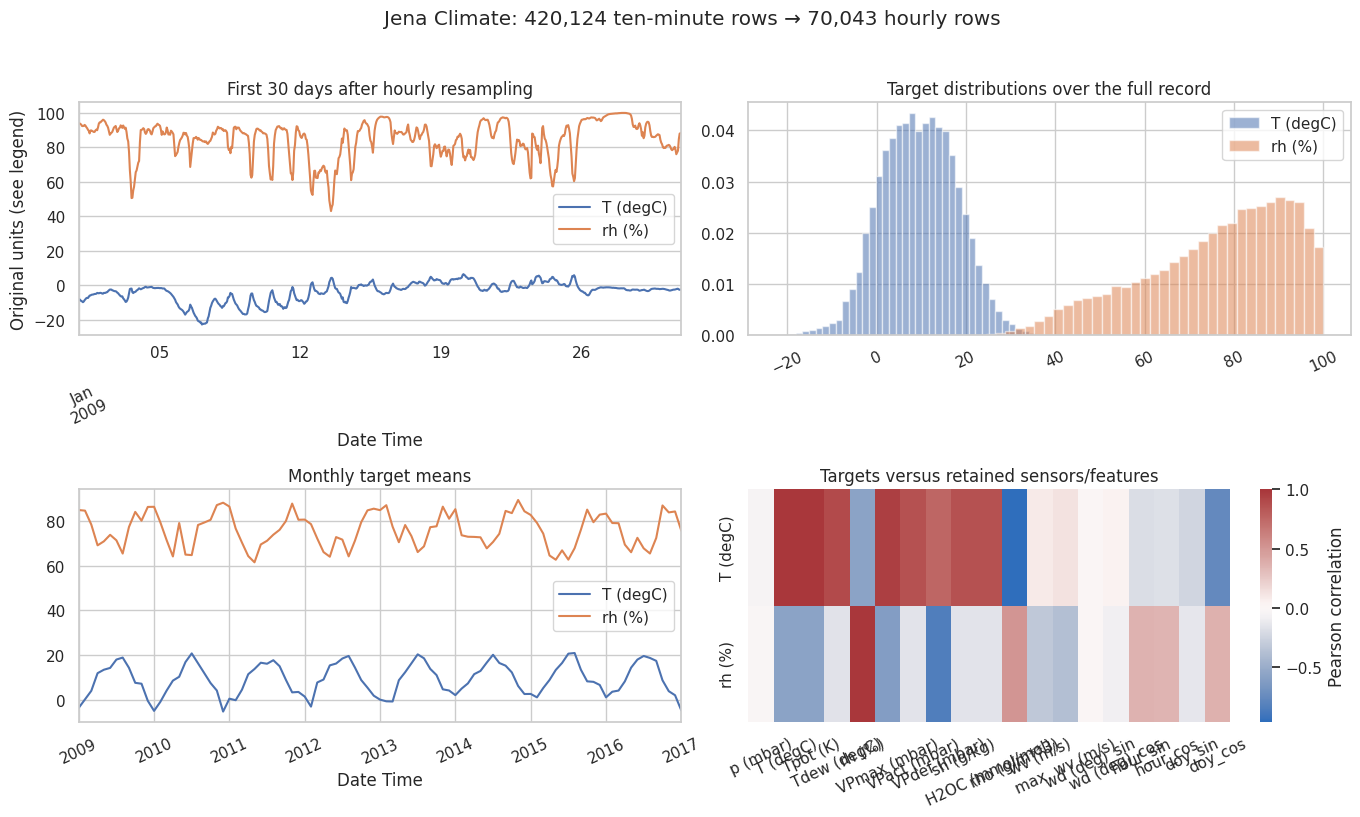

In [ ]:
# Overview of the cleaned hourly targets and retained multivariate sensor set.
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
hourly[TARGETS].iloc[:24 * 30].plot(ax=axes[0, 0], title="First 30 days after hourly resampling")
axes[0, 0].set_ylabel("Original units (see legend)")
for target in TARGETS:
    axes[0, 1].hist(hourly[target], bins=40, alpha=0.55, density=True, label=target)
axes[0, 1].legend()
axes[0, 1].set_title("Target distributions over the full record")
monthly_targets = hourly[TARGETS].resample("MS").mean()
monthly_targets.plot(ax=axes[1, 0], title="Monthly target means")
sensor_corr = hourly.corr(numeric_only=True).loc[TARGETS, feature_names if "feature_names" in globals() else hourly.columns]
sns.heatmap(sensor_corr, center=0, cmap="vlag", ax=axes[1, 1], cbar_kws={"label": "Pearson correlation"})
axes[1, 1].set_title("Targets versus retained sensors/features")
for ax in axes.flat:
    ax.tick_params(axis="x", rotation=25)
fig.suptitle(f"Jena Climate: {len(raw):,} ten-minute rows → {len(hourly):,} hourly rows", y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "data_overview.png", dpi=180, bbox_inches="tight")
plt.show()

## 2. Chronological split, train-only scaling, and aligned windows

For a target start index `i`, the input is exactly `[i−72, i)` and the target is `[i, i+12)`. The `tf.data` pipeline stores the hourly arrays once and slices each window lazily in `map`; it does **not** materialize a giant array of overlapping input windows. `sequence_stride` controls target-start spacing consistently for inputs, targets, and evaluation timestamps.

Validation targets begin at the 70% boundary and test targets begin at the 85% boundary. Their inputs may contain earlier historical context, which is information that would genuinely be available at forecast time. Their target windows cannot cross split ends.

In [ ]:
# Chronological boundaries and train-only standardization.
n_rows = len(hourly)
train_end = int(n_rows * 0.70)
val_end = int(n_rows * 0.85)
if train_end <= LOOKBACK or val_end + HORIZON >= n_rows:
    raise ValueError("Dataset is too short for the requested split/windows.")

feature_names = hourly.columns.tolist()
target_feature_indices = [feature_names.index(t) for t in TARGETS]
train_frame = hourly.iloc[:train_end]
feature_mean = train_frame.mean()
feature_std = train_frame.std().replace(0.0, 1.0)
target_mean = feature_mean[TARGETS].to_numpy(dtype=np.float32)
target_std = feature_std[TARGETS].to_numpy(dtype=np.float32)

X_all = ((hourly - feature_mean) / feature_std).to_numpy(dtype=np.float32)
Y_all = ((hourly[TARGETS] - feature_mean[TARGETS]) / feature_std[TARGETS]).to_numpy(dtype=np.float32)

split_specs = {
    "train": {"target_start": LOOKBACK, "target_end": train_end},
    "validation": {"target_start": train_end, "target_end": val_end},
    "test": {"target_start": val_end, "target_end": n_rows},
}

def valid_start_indices(spec):
    # stop is exclusive; i + HORIZON must be <= target_end.
    return np.arange(
        spec["target_start"], spec["target_end"] - HORIZON + 1, STRIDE, dtype=np.int64
    )

split_indices = {name: valid_start_indices(spec) for name, spec in split_specs.items()}
for name, idx in split_indices.items():
    if len(idx) == 0:
        raise ValueError(f"No windows for {name}")
    assert idx[0] - LOOKBACK >= 0
    assert idx[-1] + HORIZON <= split_specs[name]["target_end"]

split_summary = {
    "row_boundaries": {"train_end_exclusive": train_end, "validation_end_exclusive": val_end, "total": n_rows},
    "time_ranges": {
        "train": [str(hourly.index[0]), str(hourly.index[train_end - 1])],
        "validation": [str(hourly.index[train_end]), str(hourly.index[val_end - 1])],
        "test": [str(hourly.index[val_end]), str(hourly.index[-1])],
    },
    "window_counts": {k: int(len(v)) for k, v in split_indices.items()},
    "lookback_hours": LOOKBACK,
    "forecast_hours": HORIZON,
    "sequence_stride": STRIDE,
    "scaler_fit_rows": [0, train_end],
}
(OUTPUT_DIR / "config.json").write_text(json.dumps(CFG, indent=2))
(OUTPUT_DIR / "split_summary.json").write_text(json.dumps(split_summary, indent=2))
split_summary_df = pd.DataFrame([
    {
        "split": name,
        "first_row_timestamp": split_summary["time_ranges"][name][0],
        "last_row_timestamp": split_summary["time_ranges"][name][1],
        "target_start_index": spec["target_start"],
        "target_end_index_exclusive": spec["target_end"],
        "window_count": len(split_indices[name]),
        "lookback_hours": LOOKBACK,
        "forecast_hours": HORIZON,
        "window_stride_hours": STRIDE,
        "normalization_fit": "training rows only",
    }
    for name, spec in split_specs.items()
])
split_summary_df.to_csv(OUTPUT_DIR / "split_summary.csv", index=False)
print(json.dumps(split_summary, indent=2))
display(split_summary_df)

{
  "row_boundaries": {
    "train_end_exclusive": 49030,
    "validation_end_exclusive": 59536,
    "total": 70043
  },
  "time_ranges": {
    "train": [
      "2009-01-01 00:00:00",
      "2014-08-05 21:00:00"
    ],
    "validation": [
      "2014-08-05 22:00:00",
      "2015-10-18 10:00:00"
    ],
    "test": [
      "2015-10-18 11:00:00",
      "2017-01-01 00:00:00"
    ]
  },
  "window_counts": {
    "train": 48947,
    "validation": 10495,
    "test": 10496
  },
  "lookback_hours": 72,
  "forecast_hours": 12,
  "sequence_stride": 1,
  "scaler_fit_rows": [
    0,
    49030
  ]
}


,split,first_row_timestamp,last_row_timestamp,target_start_index,target_end_index_exclusive,window_count,lookback_hours,forecast_hours,window_stride_hours,normalization_fit
0,train,2009-01-01 00:00:00,2014-08-05 21:00:00,72,49030,48947,72,12,1,training rows only
1,validation,2014-08-05 22:00:00,2015-10-18 10:00:00,49030,59536,10495,72,12,1,training rows only
2,test,2015-10-18 11:00:00,2017-01-01 00:00:00,59536,70043,10496,72,12,1,training rows only


In [ ]:
# Lazy, exactly aligned tf.data windows. Only the training dataset shuffles.
X_TENSOR = tf.constant(X_all)
Y_TENSOR = tf.constant(Y_all)
AUTOTUNE = tf.data.AUTOTUNE

def make_window_dataset(name, training=False):
    idx = split_indices[name]
    ds = tf.data.Dataset.from_tensor_slices(idx)
    if training:
        ds = ds.shuffle(min(len(idx), 10_000), seed=SEED, reshuffle_each_iteration=True)

    def slice_window(i):
        x = X_TENSOR[i - LOOKBACK:i]
        y = Y_TENSOR[i:i + HORIZON]
        x = tf.ensure_shape(x, (LOOKBACK, len(feature_names)))
        y = tf.ensure_shape(y, (HORIZON, len(TARGETS)))
        return x, y

    options = tf.data.Options()
    options.experimental_deterministic = not training
    return (ds.map(slice_window, num_parallel_calls=AUTOTUNE)
              .batch(CFG["batch_size"])
              .prefetch(AUTOTUNE)
              .with_options(options))

train_ds = make_window_dataset("train", training=True)
val_ds = make_window_dataset("validation")
test_ds = make_window_dataset("test")

sample_x, sample_y = next(iter(val_ds))
assert sample_x.shape[1:] == (LOOKBACK, len(feature_names))
assert sample_y.shape[1:] == (HORIZON, len(TARGETS))
first_val_i = split_indices["validation"][0]
np.testing.assert_allclose(sample_x[0].numpy(), X_all[first_val_i - LOOKBACK:first_val_i])
np.testing.assert_allclose(sample_y[0].numpy(), Y_all[first_val_i:first_val_i + HORIZON])
print("Verified shapes and first validation window alignment:", sample_x.shape, sample_y.shape)

Verified shapes and first validation window alignment: (128, 72, 19) (128, 12, 2)


## 3. Controlled baselines and recurrent architectures

All neural models use the same hidden width, dropout, Adam learning rate, loss, batch size, maximum epochs, early stopping rule, and checkpoint policy. Architectural differences are limited to the recurrent cell and output mechanism needed for each comparison.

- **Persistence:** repeats the last observed temperature/humidity for all 12 horizons.
- **Direct LSTM / GRU:** one recurrent summary directly predicts all 24 outputs.
- **Seq2Seq LSTM:** encodes history, repeats the context, and decodes a future sequence.
- **Original attention model:** an LSTM emits 72 states. Twelve distinct learned horizon embeddings become additive-attention queries conditioned on the final state. Its analysis model exposes scores with shape `batch × 12 × 72`.

In [ ]:
# Model builders and horizon-specific additive temporal attention.
N_FEATURES = len(feature_names)
N_TARGETS = len(TARGETS)
UNITS = CFG["units"]
DROPOUT = CFG["dropout"]

@keras.utils.register_keras_serializable(package="JenaRNN")
class HorizonAdditiveAttention(layers.Layer):
    def __init__(self, units, horizon, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.horizon = horizon
        self.key_projection = layers.Dense(units, use_bias=False)
        self.query_projection = layers.Dense(units, use_bias=False)
        self.score_projection = layers.Dense(1, use_bias=False)
        self.horizon_embedding = layers.Embedding(horizon, units)
        self.query_fusion = layers.Dense(units, activation="tanh")

    def call(self, inputs):
        sequence, final_state = inputs  # [B,72,U], [B,U]
        batch = tf.shape(sequence)[0]
        horizon_ids = tf.range(self.horizon)
        learned_queries = self.horizon_embedding(horizon_ids)  # [12,U], distinct by horizon
        learned_queries = tf.tile(learned_queries[None, :, :], [batch, 1, 1])
        state = tf.tile(final_state[:, None, :], [1, self.horizon, 1])
        queries = self.query_fusion(tf.concat([state, learned_queries], axis=-1))
        energy = self.score_projection(
            tf.nn.tanh(
                self.key_projection(sequence)[:, None, :, :]
                + self.query_projection(queries)[:, :, None, :]
            )
        )
        scores = tf.nn.softmax(tf.squeeze(energy, axis=-1), axis=-1)  # [B,12,72]
        context = tf.einsum("bhl,blu->bhu", scores, sequence)
        return context, scores

    def get_config(self):
        return {**super().get_config(), "units": self.units, "horizon": self.horizon}


def compile_model(model):
    model.compile(
        optimizer=keras.optimizers.Adam(CFG["learning_rate"]),
        loss="mse",
        metrics=[keras.metrics.MeanAbsoluteError(name="scaled_mae")],
    )
    return model


def build_direct(cell_type):
    inputs = keras.Input((LOOKBACK, N_FEATURES), name="history")
    rnn_cls = layers.LSTM if cell_type == "lstm" else layers.GRU
    x = rnn_cls(UNITS, dropout=DROPOUT, name=f"{cell_type}_encoder")(inputs)
    x = layers.Dense(HORIZON * N_TARGETS, name="direct_projection")(x)
    outputs = layers.Reshape((HORIZON, N_TARGETS), name="forecast")(x)
    return compile_model(keras.Model(inputs, outputs, name=f"direct_{cell_type}"))


def build_seq2seq():
    inputs = keras.Input((LOOKBACK, N_FEATURES), name="history")
    context, state_h, state_c = layers.LSTM(
        UNITS, dropout=DROPOUT, return_state=True, name="encoder"
    )(inputs)
    repeated = layers.RepeatVector(HORIZON, name="repeat_context")(context)
    decoded = layers.LSTM(
        UNITS, dropout=DROPOUT, return_sequences=True, name="decoder"
    )(repeated, initial_state=[state_h, state_c])
    outputs = layers.TimeDistributed(layers.Dense(N_TARGETS), name="forecast")(decoded)
    return compile_model(keras.Model(inputs, outputs, name="seq2seq_lstm"))


def build_attention():
    inputs = keras.Input((LOOKBACK, N_FEATURES), name="history")
    sequence, state_h, _ = layers.LSTM(
        UNITS, dropout=DROPOUT, return_sequences=True, return_state=True, name="encoder"
    )(inputs)
    context, scores = HorizonAdditiveAttention(UNITS, HORIZON, name="horizon_attention")(
        [sequence, state_h]
    )
    state_repeated = layers.RepeatVector(HORIZON)(state_h)
    fused = layers.Concatenate()([context, state_repeated])
    fused = layers.TimeDistributed(layers.Dense(UNITS, activation="relu"), name="fusion")(fused)
    outputs = layers.TimeDistributed(layers.Dense(N_TARGETS), name="forecast")(fused)
    train_model = compile_model(keras.Model(inputs, outputs, name="horizon_attention_lstm"))
    analysis_model = keras.Model(inputs, [outputs, scores], name="attention_analysis")
    return train_model, analysis_model

models = {
    "Direct LSTM": build_direct("lstm"),
    "Direct GRU": build_direct("gru"),
    "Seq2Seq LSTM": build_seq2seq(),
}
attention_model, attention_analysis_model = build_attention()
models["Horizon Attention LSTM"] = attention_model

parameter_counts = {name: int(model.count_params()) for name, model in models.items()}
print(pd.Series(parameter_counts, name="parameters"))
assert attention_analysis_model.output_shape[1] == (None, HORIZON, LOOKBACK)

Direct LSTM               23064
Direct GRU                17880
Seq2Seq LSTM              54658
Horizon Attention LSTM    47170
Name: parameters, dtype: int64


## 4. Training policy and checkpoints

Early stopping monitors validation loss and restores the best weights. A matching best-weight checkpoint is retained for every model. Runtime and actual epoch count are recorded; parameter count is architectural and independent of timing. FAST mode is intended for iteration, while full mode uses stride 1, 64 units, and up to 30 epochs.

Epoch 1/30
383/383 - 7s - 17ms/step - loss: 0.2606 - scaled_mae: 0.3694 - val_loss: 0.1669 - val_scaled_mae: 0.2907 - learning_rate: 0.0010
Epoch 2/30
383/383 - 4s - 11ms/step - loss: 0.1727 - scaled_mae: 0.2972 - val_loss: 0.1548 - val_scaled_mae: 0.2746 - learning_rate: 0.0010
Epoch 3/30
383/383 - 5s - 14ms/step - loss: 0.1611 - scaled_mae: 0.2845 - val_loss: 0.1514 - val_scaled_mae: 0.2697 - learning_rate: 0.0010
Epoch 4/30
383/383 - 4s - 11ms/step - loss: 0.1541 - scaled_mae: 0.2765 - val_loss: 0.1506 - val_scaled_mae: 0.2675 - learning_rate: 0.0010
Epoch 5/30
383/383 - 5s - 13ms/step - loss: 0.1491 - scaled_mae: 0.2712 - val_loss: 0.1511 - val_scaled_mae: 0.2646 - learning_rate: 0.0010
Epoch 6/30
383/383 - 6s - 16ms/step - loss: 0.1452 - scaled_mae: 0.2668 - val_loss: 0.1531 - val_scaled_mae: 0.2651 - learning_rate: 0.0010
Epoch 7/30
383/383 - 4s - 11ms/step - loss: 0.1415 - scaled_mae: 0.2629 - val_loss: 0.1559 - val_scaled_mae: 0.2718 - learning_rate: 0.0010
Epoch 8/30
383/383 -

,model,parameters,epochs_run,runtime_seconds,best_val_loss_scaled,checkpoint
0,Direct LSTM,23064,10,61.477353,0.150613,/content/jena_rnn_outputs/models/direct_lstm.b...
1,Direct GRU,17880,16,82.007649,0.143472,/content/jena_rnn_outputs/models/direct_gru.be...
2,Seq2Seq LSTM,54658,10,69.239999,0.147000,/content/jena_rnn_outputs/models/seq2seq_lstm....
3,Horizon Attention LSTM,47170,10,81.298893,0.150431,/content/jena_rnn_outputs/models/horizon_atten...


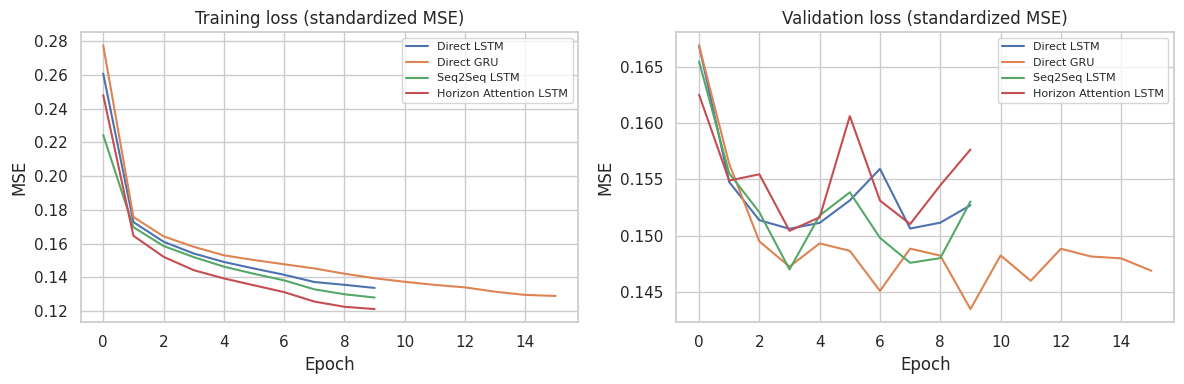

In [ ]:
# Train each neural model under the same policy.
training_records = []
histories = {}
for name, model in models.items():
    safe_name = name.lower().replace(" ", "_")
    checkpoint = MODEL_DIR / f"{safe_name}.best.weights.h5"
    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=CFG["patience"], restore_best_weights=True
        ),
        keras.callbacks.ModelCheckpoint(
            checkpoint, monitor="val_loss", save_best_only=True, save_weights_only=True
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=max(1, CFG["patience"] // 2), min_lr=1e-5
        ),
    ]
    started = time.perf_counter()
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=CFG["epochs"],
        callbacks=callbacks,
        verbose=2,
    )
    runtime = time.perf_counter() - started
    model.save(MODEL_DIR / f"{safe_name}.keras")
    histories[name] = history.history
    training_records.append({
        "model": name,
        "parameters": parameter_counts[name],
        "epochs_run": len(history.history["loss"]),
        "runtime_seconds": runtime,
        "best_val_loss_scaled": float(min(history.history["val_loss"])),
        "checkpoint": str(checkpoint),
    })

training_df = pd.DataFrame(training_records)
training_df.to_csv(OUTPUT_DIR / "training_summary.csv", index=False)
display(training_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for model_name, history_values in histories.items():
    axes[0].plot(history_values["loss"], label=model_name)
    axes[1].plot(history_values["val_loss"], label=model_name)
axes[0].set_title("Training loss (standardized MSE)")
axes[1].set_title("Validation loss (standardized MSE)")
for ax in axes:
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE")
    ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "training_curves.png", dpi=180)
plt.show()

## 5. Evaluation in original units

MAE and RMSE are reported separately for every target and horizon, preserving °C and percentage-point units. The cross-target summary used for compact comparison is **normalized aggregate MAE (NMAE)**: each original-unit MAE is divided by that target's training standard deviation, then averaged. NMAE is dimensionless and is never presented as an original-unit error.

Model selection for uncertainty analysis uses **validation NMAE only**. Test metrics are not consulted.

In [ ]:
# Prediction helpers, persistence baseline, and long-form metrics.
def inverse_targets(values):
    return values * target_std[None, None, :] + target_mean[None, None, :]


def collect_xy(ds):
    ys = []
    xs = []
    for xb, yb in ds:
        xs.append(xb.numpy())
        ys.append(yb.numpy())
    return np.concatenate(xs), np.concatenate(ys)


def metric_rows(model_name, split_name, y_true_scaled, y_pred_scaled):
    y_true = inverse_targets(y_true_scaled)
    y_pred = inverse_targets(y_pred_scaled)
    rows = []
    for h in range(HORIZON):
        for j, target in enumerate(TARGETS):
            err = y_true[:, h, j] - y_pred[:, h, j]
            mae = float(np.mean(np.abs(err)))
            rows.append({
                "model": model_name,
                "split": split_name,
                "horizon_hour": h + 1,
                "target": target,
                "mae_original_units": mae,
                "rmse_original_units": float(np.sqrt(np.mean(np.square(err)))),
                "normalized_mae_by_train_std": mae / float(target_std[j]),
                "n_samples": int(len(err)),
            })
    return rows

val_x, val_y = collect_xy(val_ds)
test_x, test_y = collect_xy(test_ds)
all_metric_rows = []
predictions = {"validation": {}, "test": {}}

# Persistence repeats the last observed target values; target columns share train scaling.
for split_name, x, y in [("validation", val_x, val_y), ("test", test_x, test_y)]:
    last = x[:, -1, target_feature_indices]
    persistence = np.repeat(last[:, None, :], HORIZON, axis=1)
    predictions[split_name]["Persistence"] = persistence
    all_metric_rows.extend(metric_rows("Persistence", split_name, y, persistence))

for name, model in models.items():
    for split_name, ds, y in [("validation", val_ds, val_y), ("test", test_ds, test_y)]:
        pred = model.predict(ds, verbose=0)
        if pred.shape != y.shape:
            raise ValueError(f"Prediction alignment failure for {name}/{split_name}: {pred.shape} vs {y.shape}")
        predictions[split_name][name] = pred
        all_metric_rows.extend(metric_rows(name, split_name, y, pred))

metrics_df = pd.DataFrame(all_metric_rows)
metrics_df.to_csv(OUTPUT_DIR / "forecast_metrics.csv", index=False)
aggregate_df = (metrics_df.groupby(["model", "split"], as_index=False)
                ["normalized_mae_by_train_std"].mean()
                .rename(columns={"normalized_mae_by_train_std": "aggregate_nmae_dimensionless"}))
aggregate_df.to_csv(OUTPUT_DIR / "metrics_aggregate_normalized.csv", index=False)
protocol_rows = pd.DataFrame([{
    "model": "Persistence", "parameters": 0, "epochs_run": 0,
    "runtime_seconds": 0.0, "best_val_loss_scaled": np.nan,
    "checkpoint": "not applicable",
}])
comparison_training = pd.concat([protocol_rows, training_df], ignore_index=True)
comparison_wide = aggregate_df.pivot(index="model", columns="split", values="aggregate_nmae_dimensionless").reset_index()
comparison_wide = comparison_wide.rename(columns={"validation": "validation_standardized_mae", "test": "test_standardized_mae"})
model_comparison_df = comparison_training.merge(comparison_wide, on="model", how="left")
model_comparison_df["shared_neural_protocol"] = "Adam; standardized MSE; early stopping on val_loss; same width/dropout/batch/epochs"
model_comparison_df.to_csv(OUTPUT_DIR / "model_comparison.csv", index=False)

key_table = metrics_df[metrics_df["horizon_hour"].isin(KEY_HORIZONS)].copy()
display(key_table.pivot_table(
    index=["model", "split", "target"], columns="horizon_hour",
    values=["mae_original_units", "rmse_original_units"]
).round(3))
display(aggregate_df.sort_values(["split", "aggregate_nmae_dimensionless"]))

mae_original_units                 \
horizon_hour                                               1      3       6    
model                  split      target                                       
Direct GRU             test       T (degC)              0.553  0.917   1.329   
                                  rh (%)                2.323  4.248   5.817   
                       validation T (degC)              0.556  0.955   1.390   
                                  rh (%)                2.423  4.565   6.236   
Direct LSTM            test       T (degC)              0.662  1.004   1.388   
                                  rh (%)                2.451  4.376   5.936   
                       validation T (degC)              0.700  1.073   1.458   
                                  rh (%)                2.612  4.661   6.401   
Horizon Attention LSTM test       T (degC)              0.833  1.096   1.409   
                                  rh (%)                3.066  4.526   5.937   
                       validation T (degC)              0.808  1.103   1.443   
                                  rh (%)                3.357  4.891   6.344   
Persistence            test       T (degC)              0.643  1.721   2.997   
                                  rh (%)                2.773  7.070  11.938   
                       validation T (degC)              0.687  1.854   3.259   
                                  rh (%)                2.929  7.494  12.755   
Seq2Seq LSTM           test       T (degC)              0.643  0.994   1.388   
                                  rh (%)                2.766  4.363   5.886   
                       validation T (degC)              0.646  1.015   1.401   
                                  rh (%)                2.976  4.706   6.282   

                                                   rmse_original_units  \
horizon_hour                                    12                  1    
model                  split      target                                 
Direct GRU             test       T (degC)   1.783               0.725   
                                  rh (%)     7.292               3.171   
                       validation T (degC)   1.886               0.746   
                                  rh (%)     7.726               3.384   
Direct LSTM            test       T (degC)   1.836               0.861   
                                  rh (%)     7.393               3.351   
                       validation T (degC)   1.952               0.930   
                                  rh (%)     7.845               3.606   
Horizon Attention LSTM test       T (degC)   1.806               1.056   
                                  rh (%)     7.260               4.138   
                       validation T (degC)   1.897               1.039   
                                  rh (%)     7.696               4.430   
Persistence            test       T (degC)   4.188               0.901   
                                  rh (%)    16.442               3.976   
                       validation T (degC)   4.550               0.972   
                                  rh (%)    17.638               4.287   
Seq2Seq LSTM           test       T (degC)   1.842               0.839   
                                  rh (%)     7.266               3.765   
                       validation T (degC)   1.941               0.862   
                                  rh (%)     7.778               4.010   

                                                                    
horizon_hour                                    3       6       12  
model                  split      target                            
Direct GRU             test       T (degC)   1.220   1.717   2.286  
                                  rh (%)     5.861   7.797   9.537  
                       validation T (degC)   1.298   1.831   2.440  
                                  rh (%)     6.214   8.239  10.009  
Direct LSTM     

,model,split,aggregate_nmae_dimensionless
0,Direct GRU,test,0.243187
8,Seq2Seq LSTM,test,0.250134
2,Direct LSTM,test,0.252162
4,Horizon Attention LSTM,test,0.255152
6,Persistence,test,0.513534
1,Direct GRU,validation,0.258642
9,Seq2Seq LSTM,validation,0.263985
3,Direct LSTM,validation,0.267466
5,Horizon Attention LSTM,validation,0.269630
7,Persistence,validation,0.551832


In [ ]:
# Select the best neural model using validation NMAE only (never test performance).
neural_names = list(models)
val_selection = (aggregate_df[
    (aggregate_df["split"] == "validation") & aggregate_df["model"].isin(neural_names)
].sort_values("aggregate_nmae_dimensionless"))
best_model_name = val_selection.iloc[0]["model"]
selection_record = {
    "criterion": "minimum validation aggregate NMAE (mean target/horizon MAE divided by train target std)",
    "best_neural_model": best_model_name,
    "validation_scores": dict(zip(val_selection["model"], val_selection["aggregate_nmae_dimensionless"])),
    "test_metrics_used_for_selection": False,
}
(OUTPUT_DIR / "model_selection.json").write_text(json.dumps(selection_record, indent=2))
print(json.dumps(selection_record, indent=2))

{
  "criterion": "minimum validation aggregate NMAE (mean target/horizon MAE divided by train target std)",
  "best_neural_model": "Direct GRU",
  "validation_scores": {
    "Direct GRU": 0.25864187652963083,
    "Seq2Seq LSTM": 0.2639849074253724,
    "Direct LSTM": 0.2674663181989343,
    "Horizon Attention LSTM": 0.26963022530135045
  },
  "test_metrics_used_for_selection": false
}


## 6. Horizon curves and prediction examples

These cells make comparisons rather than assuming attention wins. In the report, quote the actual curves/tables: state where the attention model improves, ties, or worsens relative to controlled recurrent alternatives and persistence.

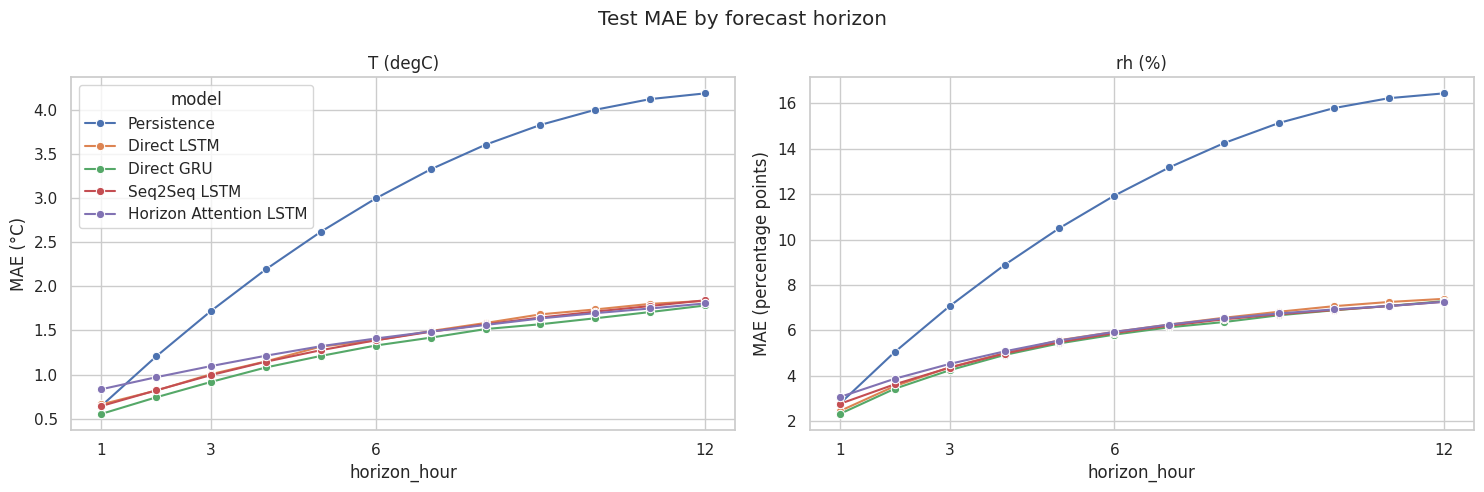

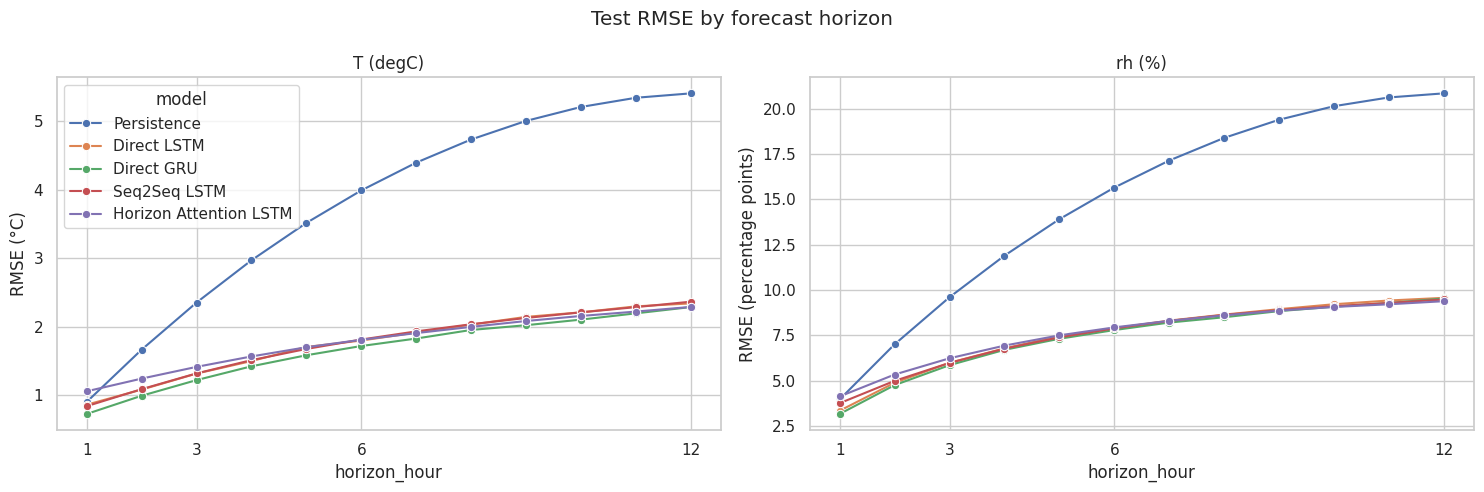

In [ ]:
# Horizon error curves: separate axes preserve target units; no cross-target unit averaging.
sns.set_theme(style="whitegrid")
for metric_col, filename, metric_label in [
    ("mae_original_units", "horizon_mae.png", "MAE"),
    ("rmse_original_units", "horizon_rmse.png", "RMSE"),
]:
    fig, axes = plt.subplots(1, N_TARGETS, figsize=(15, 5), sharex=True)
    for j, target in enumerate(TARGETS):
        subset = metrics_df[(metrics_df["split"] == "test") & (metrics_df["target"] == target)]
        sns.lineplot(data=subset, x="horizon_hour", y=metric_col, hue="model", marker="o", ax=axes[j])
        unit = "°C" if target == "T (degC)" else "percentage points"
        axes[j].set_title(target)
        axes[j].set_ylabel(f"{metric_label} ({unit})")
        axes[j].set_xticks(KEY_HORIZONS)
        if j:
            axes[j].get_legend().remove()
    fig.suptitle(f"Test {metric_label} by forecast horizon")
    fig.tight_layout()
    fig.savefig(FIG_DIR / filename, dpi=180)
    plt.show()

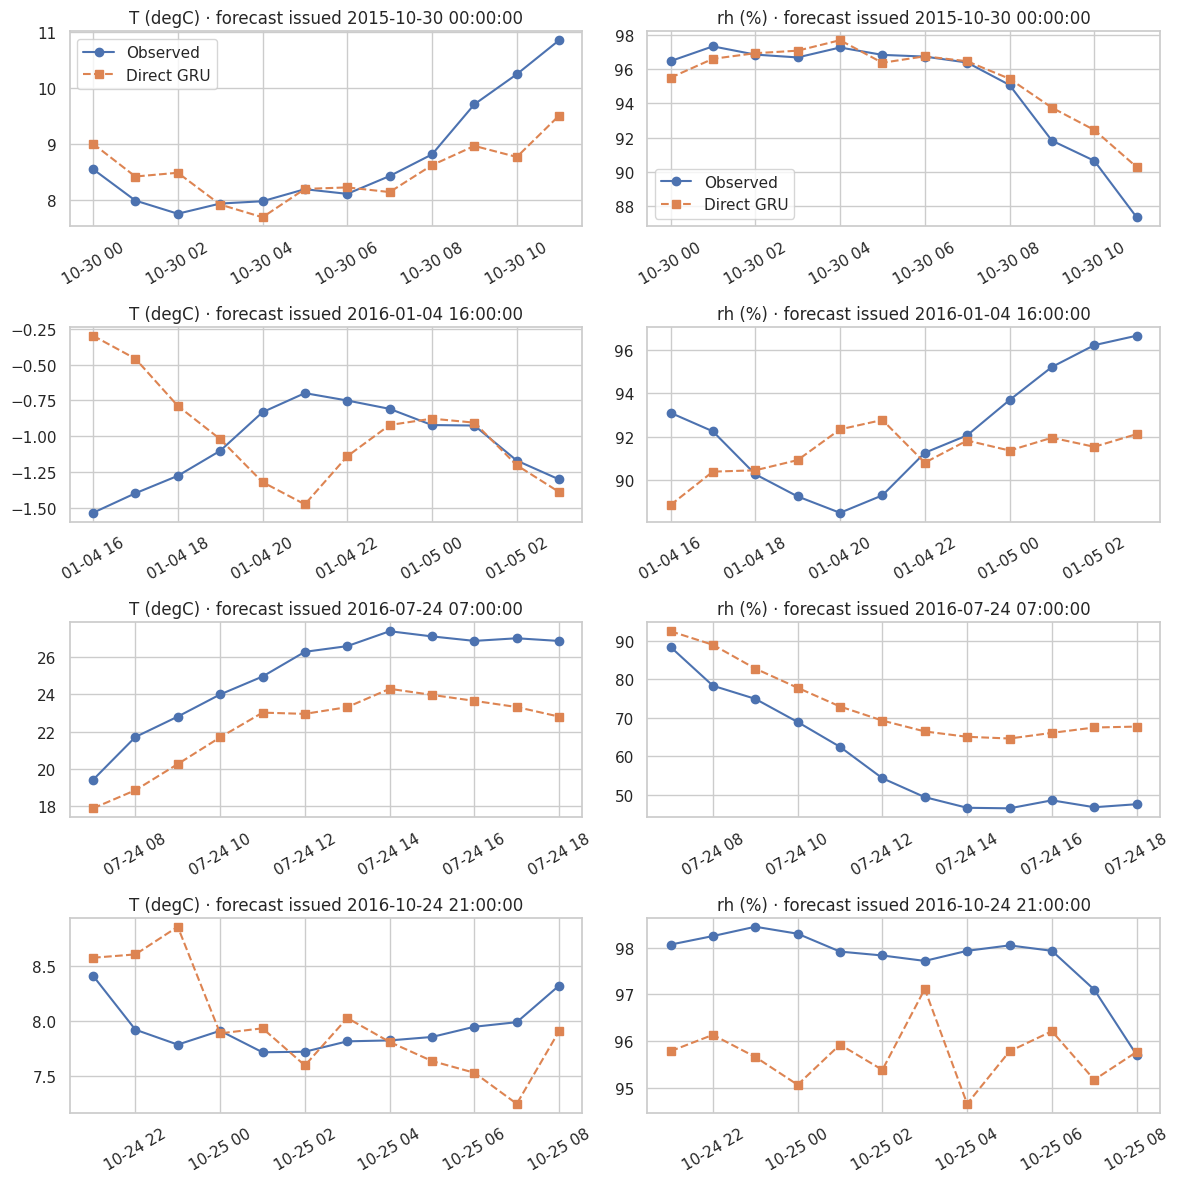

In [ ]:
# Compact prediction examples at all horizons for the validation-selected model.
rng = np.random.default_rng(SEED)
example_ids = np.sort(rng.choice(len(test_y), size=min(4, len(test_y)), replace=False))
y_true_test = inverse_targets(test_y)
y_pred_best = inverse_targets(predictions["test"][best_model_name])
test_start_times = hourly.index[split_indices["test"]]

fig, axes = plt.subplots(len(example_ids), N_TARGETS, figsize=(12, 3 * len(example_ids)), squeeze=False)
for row, sample_id in enumerate(example_ids):
    future_times = hourly.index[split_indices["test"][sample_id]:split_indices["test"][sample_id] + HORIZON]
    for j, target in enumerate(TARGETS):
        ax = axes[row, j]
        ax.plot(future_times, y_true_test[sample_id, :, j], "o-", label="Observed")
        ax.plot(future_times, y_pred_best[sample_id, :, j], "s--", label=best_model_name)
        ax.set_title(f"{target} · forecast issued {test_start_times[sample_id]}")
        ax.tick_params(axis="x", rotation=30)
        if row == 0:
            ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "prediction_examples.png", dpi=180)
plt.show()

## 7. Attention analysis

Attention weights are associations inside this predictor, not causal explanations. A peak at look-back 1 means the most recent hour; a peak near 24/48/72 may be consistent with daily recurrence. Interpretation should compare average patterns and individual heatmaps with errors—not cherry-pick one attractive example.

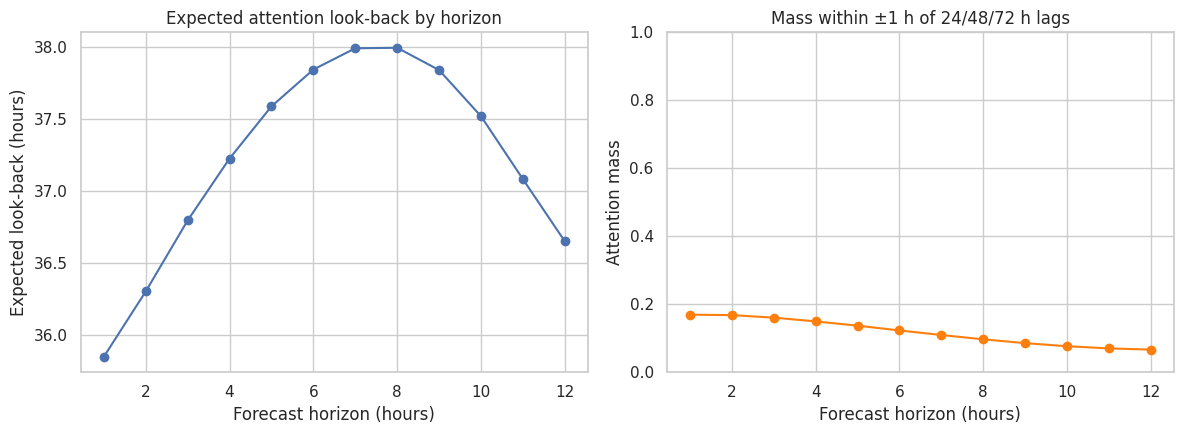

In [ ]:
# Extract attention scores [samples, 12 horizons, 72 look-back hours].
attention_predictions, attention_scores = attention_analysis_model.predict(test_ds, verbose=0)
assert attention_scores.shape == (len(test_y), HORIZON, LOOKBACK)
np.testing.assert_allclose(attention_predictions, predictions["test"]["Horizon Attention LSTM"], rtol=1e-5, atol=1e-5)
average_attention = attention_scores.mean(axis=0)
lookback_hours = np.arange(LOOKBACK, 0, -1)

attention_summary = pd.DataFrame(
    average_attention,
    index=[f"h+{h}" for h in range(1, HORIZON + 1)],
    columns=[f"lag_{lag}h" for lag in lookback_hours],
)
attention_summary.to_csv(OUTPUT_DIR / "attention_average_weights.csv")
expected_lag = np.sum(average_attention * lookback_hours[None, :], axis=1)
daily_mask = np.zeros(LOOKBACK, dtype=bool)
for daily_lag in (24, 48, 72):
    daily_mask |= np.abs(lookback_hours - daily_lag) <= 1
daily_lag_mass = average_attention[:, daily_mask].sum(axis=1)
attention_diagnostics = pd.DataFrame({
    'horizon_hour': np.arange(1, HORIZON + 1),
    'expected_lookback_hours': expected_lag,
    'mass_near_24_48_72h_lags': daily_lag_mass,
})
attention_diagnostics.to_csv(OUTPUT_DIR / 'attention_diagnostics.csv', index=False)
np.savez_compressed(
    OUTPUT_DIR / "attention_compact_samples.npz",
    scores=attention_scores[:min(256, len(attention_scores))].astype(np.float16),
    start_indices=split_indices["test"][:min(256, len(attention_scores))],
)


fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(np.arange(1, HORIZON + 1), expected_lag, 'o-')
axes[0].set(xlabel='Forecast horizon (hours)', ylabel='Expected look-back (hours)',
            title='Expected attention look-back by horizon')
axes[1].plot(np.arange(1, HORIZON + 1), daily_lag_mass, 'o-', color='tab:orange')
axes[1].set(xlabel='Forecast horizon (hours)', ylabel='Attention mass',
            title='Mass within ±1 h of 24/48/72 h lags', ylim=(0, 1))
fig.tight_layout()
fig.savefig(FIG_DIR / "attention_lookback_summary.png", dpi=180)
plt.show()


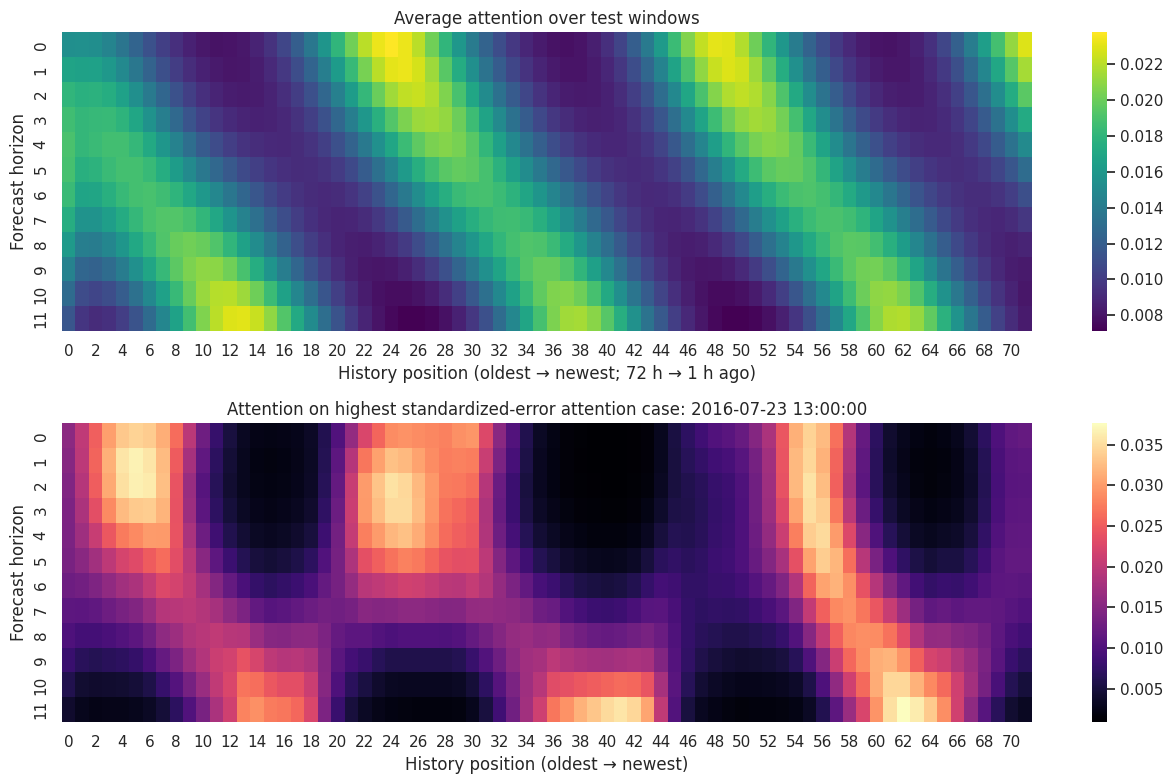

In [ ]:
# Average and individual high-error attention maps; weights are associations, not causes.
attention_true = y_true_test
attention_pred_original = inverse_targets(predictions["test"]["Horizon Attention LSTM"])
case_mae_standardized = np.mean(
    np.abs(attention_true - attention_pred_original) / target_std[None, None, :], axis=(1, 2)
)
worst_attention_id = int(np.argmax(case_mae_standardized))
fig, axes = plt.subplots(2, 1, figsize=(13, 8))
sns.heatmap(average_attention, cmap="viridis", ax=axes[0])
axes[0].set_title("Average attention over test windows")
axes[0].set_xlabel("History position (oldest → newest; 72 h → 1 h ago)")
axes[0].set_ylabel("Forecast horizon")
sns.heatmap(attention_scores[worst_attention_id], cmap="magma", ax=axes[1])
axes[1].set_title(f"Attention on highest standardized-error attention case: {test_start_times[worst_attention_id]}")
axes[1].set_xlabel("History position (oldest → newest)")
axes[1].set_ylabel("Forecast horizon")
fig.tight_layout()
fig.savefig(FIG_DIR / "attention_heatmaps.png", dpi=180)
plt.show()

## 8. Failure cases and residual-vs-change analysis

A sudden-change score is computed from the **observed future trajectory**: the maximum absolute one-hour change over the 12-hour target sequence, including the transition from the last input hour. This is used only after prediction for diagnosis. It is not an input and cannot leak into training or model selection.

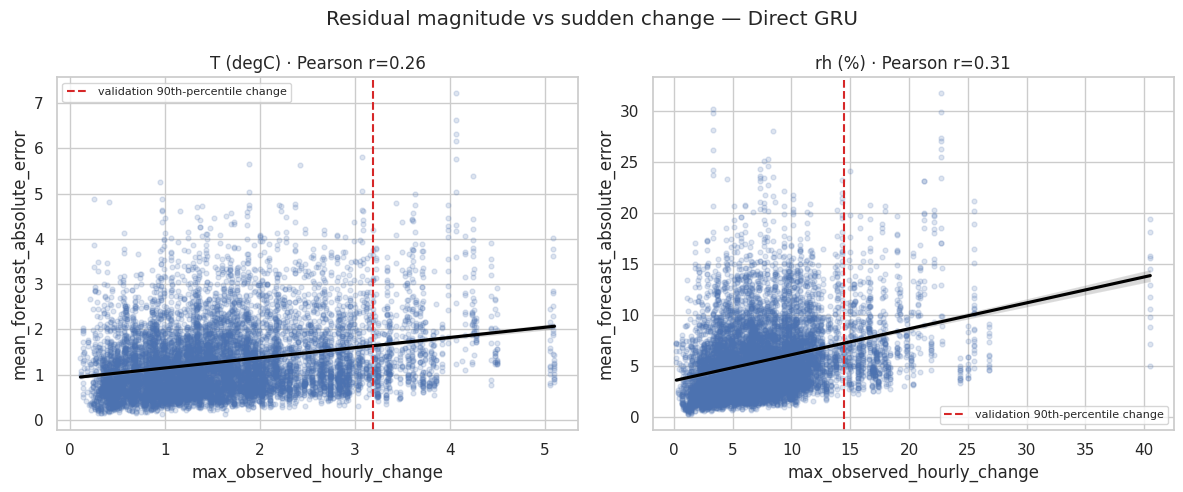

In [ ]:
# Diagnose whether errors rise around abrupt observed temperature/humidity changes.
# Thresholds are calibrated on validation trajectories, never on test outcomes.
val_true_original = inverse_targets(val_y)
last_val_observed = inverse_targets(val_x[:, -1:, target_feature_indices])
val_trajectory = np.concatenate([last_val_observed, val_true_original], axis=1)
val_max_change = np.abs(np.diff(val_trajectory, axis=1)).max(axis=1)
per_target_change_threshold = np.quantile(val_max_change, 0.90, axis=0)
validation_combined_change = np.mean(val_max_change / target_std[None, :], axis=1)
abrupt_threshold = float(np.quantile(validation_combined_change, 0.90))

last_observed_original = inverse_targets(test_x[:, -1:, target_feature_indices])
trajectory = np.concatenate([last_observed_original, y_true_test], axis=1)
hourly_changes = np.abs(np.diff(trajectory, axis=1))
max_change = hourly_changes.max(axis=1)  # [sample, target]
best_abs_error = np.mean(np.abs(y_true_test - y_pred_best), axis=1)  # [sample, target]

change_rows = []
for j, target in enumerate(TARGETS):
    for i in range(len(test_y)):
        change_rows.append({
            "sample": i,
            "forecast_start": str(test_start_times[i]),
            "target": target,
            "max_observed_hourly_change": float(max_change[i, j]),
            "mean_forecast_absolute_error": float(best_abs_error[i, j]),
        })
change_df = pd.DataFrame(change_rows)
change_df.to_csv(OUTPUT_DIR / "error_vs_change.csv", index=False)

fig, axes = plt.subplots(1, N_TARGETS, figsize=(12, 5))
for j, target in enumerate(TARGETS):
    subset = change_df[change_df["target"] == target]
    sns.regplot(
        data=subset, x="max_observed_hourly_change", y="mean_forecast_absolute_error",
        scatter_kws={"alpha": 0.18, "s": 12}, line_kws={"color": "black"}, ax=axes[j]
    )
    corr = subset[["max_observed_hourly_change", "mean_forecast_absolute_error"]].corr().iloc[0, 1]
    axes[j].axvline(per_target_change_threshold[j], color='tab:red', linestyle='--',
                       label='validation 90th-percentile change')
    axes[j].legend(fontsize=8)
    axes[j].set_title(f"{target} · Pearson r={corr:.2f}")
fig.suptitle(f"Residual magnitude vs sudden change — {best_model_name}")
fig.tight_layout()
fig.savefig(FIG_DIR / "error_vs_weather_change.png", dpi=180)
plt.show()

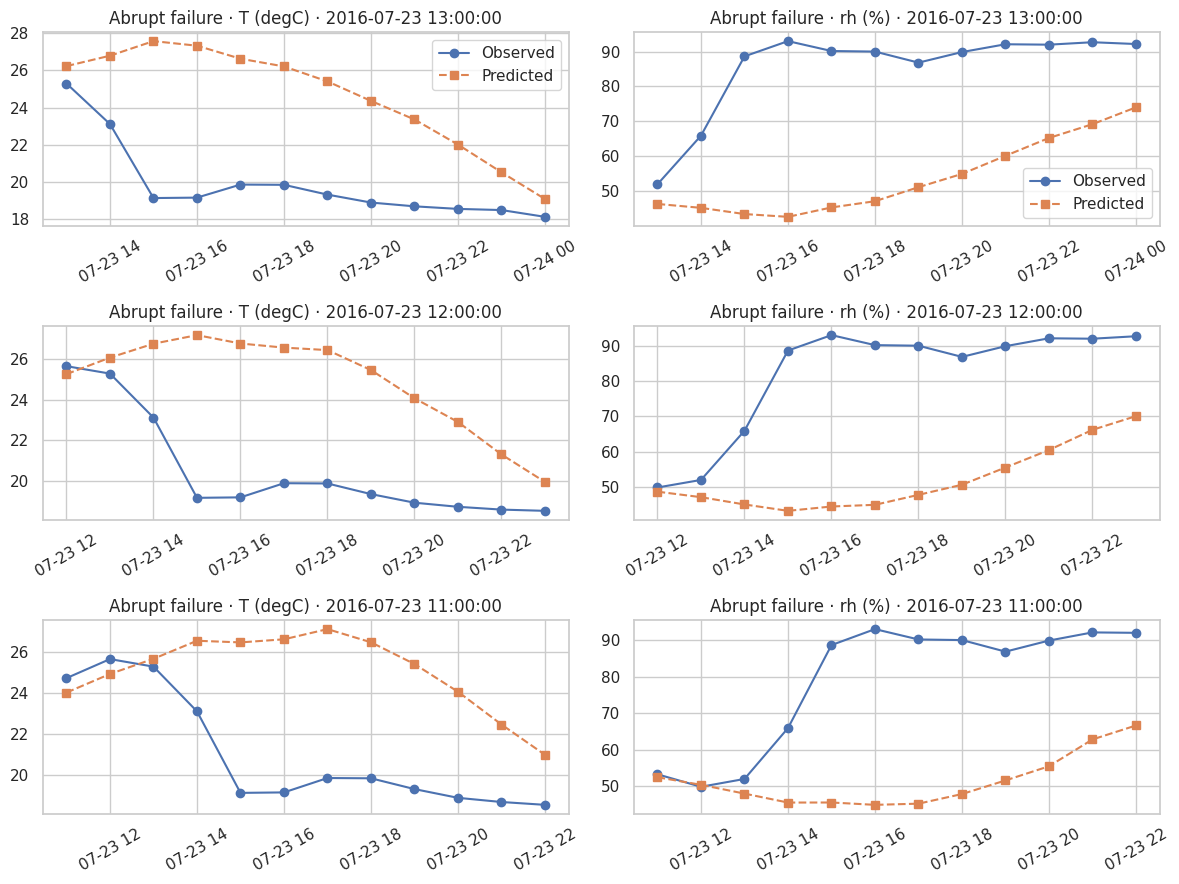

In [ ]:
# Plot top failure cases among the most abrupt 10% of test windows.
combined_change = np.mean(max_change / target_std[None, :], axis=1)
combined_error = np.mean(best_abs_error / target_std[None, :], axis=1)
abrupt_ids = np.flatnonzero(combined_change >= abrupt_threshold)
failure_ids = abrupt_ids[np.argsort(combined_error[abrupt_ids])[-3:]][::-1]

failure_records = []
fig, axes = plt.subplots(len(failure_ids), N_TARGETS, figsize=(12, 3 * len(failure_ids)), squeeze=False)
for row, sample_id in enumerate(failure_ids):
    future_times = hourly.index[split_indices["test"][sample_id]:split_indices["test"][sample_id] + HORIZON]
    failure_records.append({
        "sample": int(sample_id),
        "forecast_start": str(test_start_times[sample_id]),
        "normalized_change_score": float(combined_change[sample_id]),
        "normalized_error_score": float(combined_error[sample_id]),
    })
    for j, target in enumerate(TARGETS):
        axes[row, j].plot(future_times, y_true_test[sample_id, :, j], "o-", label="Observed")
        axes[row, j].plot(future_times, y_pred_best[sample_id, :, j], "s--", label="Predicted")
        axes[row, j].set_title(f"Abrupt failure · {target} · {test_start_times[sample_id]}")
        axes[row, j].tick_params(axis="x", rotation=30)
        if row == 0:
            axes[row, j].legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "failure_cases.png", dpi=180)
plt.show()
pd.DataFrame(failure_records).to_csv(OUTPUT_DIR / "failure_case_index.csv", index=False)

## 9. Stretch goal: conformal-style marginal residual intervals

For the validation-selected neural model, the calibration score is absolute **validation residual** separately for each target and horizon. The 90th-percentile finite-sample conformal-style quantile is added/subtracted from the point forecast. Test coverage and mean width are then reported separately by target/horizon.

These are **marginal residual intervals**, an uncertainty baseline—not a learned probabilistic density, not a joint 90% guarantee over all 24 outputs, and not guaranteed under distribution shift or serial dependence.

,selected_model,target,horizon_hour,nominal_marginal_coverage,empirical_test_coverage,mean_interval_width_original_units,calibration_samples,quantile_level_finite_sample
0,Direct GRU,T (degC),1,0.9,0.908,2.366,10495,0.9
1,Direct GRU,rh (%),1,0.9,0.904,10.182,10495,0.9
4,Direct GRU,T (degC),3,0.9,0.918,4.120,10495,0.9
5,Direct GRU,rh (%),3,0.9,0.913,19.888,10495,0.9
10,Direct GRU,T (degC),6,0.9,0.918,5.867,10495,0.9
11,Direct GRU,rh (%),6,0.9,0.913,26.706,10495,0.9
22,Direct GRU,T (degC),12,0.9,0.917,7.982,10495,0.9
23,Direct GRU,rh (%),12,0.9,0.916,33.076,10495,0.9


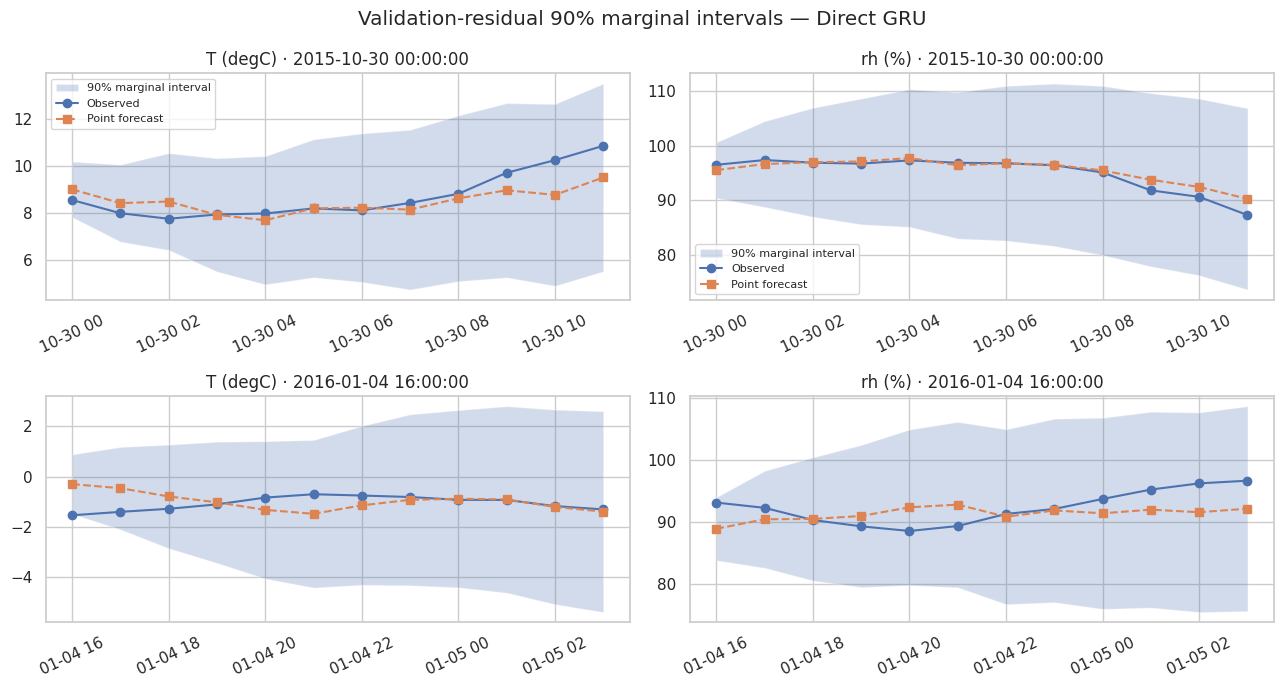

In [ ]:
# Validation-residual 90% marginal intervals; test remains untouched until evaluation.
alpha = 0.10
val_true_original = inverse_targets(val_y)
val_pred_original = inverse_targets(predictions["validation"][best_model_name])
test_pred_original = inverse_targets(predictions["test"][best_model_name])
calibration_scores = np.abs(val_true_original - val_pred_original)
n_cal = calibration_scores.shape[0]
quantile_level = min(1.0, math.ceil((n_cal + 1) * (1 - alpha)) / n_cal)
try:
    residual_quantiles = np.quantile(calibration_scores, quantile_level, axis=0, method="higher")
except TypeError:  # NumPy < 1.22 compatibility
    residual_quantiles = np.quantile(calibration_scores, quantile_level, axis=0, interpolation="higher")

lower = test_pred_original - residual_quantiles[None, :, :]
upper = test_pred_original + residual_quantiles[None, :, :]
covered = (y_true_test >= lower) & (y_true_test <= upper)
interval_rows = []
for h in range(HORIZON):
    for j, target in enumerate(TARGETS):
        interval_rows.append({
            "selected_model": best_model_name,
            "target": target,
            "horizon_hour": h + 1,
            "nominal_marginal_coverage": 0.90,
            "empirical_test_coverage": float(covered[:, h, j].mean()),
            "mean_interval_width_original_units": float(2 * residual_quantiles[h, j]),
            "calibration_samples": int(n_cal),
            "quantile_level_finite_sample": float(quantile_level),
        })
interval_df = pd.DataFrame(interval_rows)
interval_df.to_csv(OUTPUT_DIR / "interval_metrics.csv", index=False)
display(interval_df[interval_df["horizon_hour"].isin(KEY_HORIZONS)].round(3))

interval_example_ids = example_ids[:min(2, len(example_ids))]
fig, axes = plt.subplots(len(interval_example_ids), N_TARGETS, figsize=(13, 3.5 * len(interval_example_ids)), squeeze=False)
for row, sample_id in enumerate(interval_example_ids):
    future_times = hourly.index[split_indices["test"][sample_id]:split_indices["test"][sample_id] + HORIZON]
    for j, target in enumerate(TARGETS):
        axes[row, j].fill_between(future_times, lower[sample_id, :, j], upper[sample_id, :, j], alpha=0.25, label="90% marginal interval")
        axes[row, j].plot(future_times, y_true_test[sample_id, :, j], "o-", label="Observed")
        axes[row, j].plot(future_times, test_pred_original[sample_id, :, j], "s--", label="Point forecast")
        axes[row, j].set_title(f"{target} · {test_start_times[sample_id]}")
        axes[row, j].tick_params(axis="x", rotation=25)
        if row == 0:
            axes[row, j].legend(fontsize=8)
fig.suptitle(f"Validation-residual 90% marginal intervals — {best_model_name}")
fig.tight_layout()
fig.savefig(FIG_DIR / "prediction_intervals.png", dpi=180)
plt.show()

## 10. Save compact predictions, artifact map, and final ZIP

In [ ]:
# Save compact, reproducible outputs without exporting every overlapping window.
sample_count = min(1000, len(test_y))
compact = {
    "forecast_start": test_start_times[:sample_count].astype(str),
    "y_true_original": y_true_test[:sample_count].astype(np.float32),
    "best_model_prediction_original": y_pred_best[:sample_count].astype(np.float32),
    "interval_lower": lower[:sample_count].astype(np.float32),
    "interval_upper": upper[:sample_count].astype(np.float32),
}
np.savez_compressed(OUTPUT_DIR / "compact_test_predictions.npz", **compact)

artifact_map = {
    "configuration": "config.json",
    "split_and_preprocessing": ["split_summary.csv", "split_summary.json", "preprocessing_summary.json"],
    "training": ["training_summary.csv", "training_curves.png"],
    "metrics_original_units": "forecast_metrics.csv",
    "model_comparison": "model_comparison.csv",
    "validation_only_selection": "model_selection.json",
    "prediction_sample": "compact_test_predictions.npz",
    "attention": ["attention_average_weights.csv", "attention_diagnostics.csv", "attention_compact_samples.npz"],
    "uncertainty_baseline": "interval_metrics.csv",
    "diagnostics": ["error_vs_change.csv", "failure_case_index.csv"],
    "models": "models/*.keras and best checkpoints",
    "figures": "figures/*.png",
}
(OUTPUT_DIR / "preprocessing_summary.json").write_text(json.dumps(preprocess_summary, indent=2))
(OUTPUT_DIR / "artifact_map.json").write_text(json.dumps(artifact_map, indent=2))

zip_output = Path("/content/jena_rnn_outputs.zip")
if zip_output.exists():
    zip_output.unlink()
shutil.make_archive(str(zip_output.with_suffix("")), "zip", root_dir=OUTPUT_DIR)
print(f"Created {zip_output} ({zip_output.stat().st_size / 1e6:.1f} MB)")

try:
    from google.colab import files
    files.download(str(zip_output))
except ImportError:
    print("Not running in Colab; ZIP is available at", zip_output)

Created /content/jena_rnn_outputs.zip (6.8 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Required discussion questions

## 1. What may attention look back at, and should gains differ at short vs long horizons?

The learned horizon-specific queries can assign different weights over the 72 encoder states. Plausible patterns include concentration on the most recent hours for persistence and local trend, broader weighting during noisy periods, and peaks around roughly 24, 48, or 72 hours for recurring diurnal structure. Weather variables are coupled, so an encoder state can also summarize pressure, wind, vapor pressure, and other retained sensors—not only the two targets.

At short horizons, persistence and the final recurrent state are already strong inductive biases, so attention may add little and its extra parameters may even hurt. At longer horizons, choosing different historical states for each forecast lead could help avoid a single-vector bottleneck and exploit repeated daily behavior. However, this must be judged from the generated per-horizon validation/test tables and curves. In the report:

1. Compare `Horizon Attention LSTM` against direct LSTM, Seq2Seq, GRU, and persistence at 1/3/6/12 hours for both targets.
2. Inspect whether average attention shifts from recent lags toward daily lags as horizon grows.
3. State explicitly where attention improves or worsens; do not infer forecasting quality from visually appealing weights.
4. Connect high-error individual heatmaps to abrupt-change diagnostics, while avoiding causal claims.

## 2. What does the RNN sequential bias buy versus a Transformer, and when might an RNN be favored?

An RNN processes time in order and reuses one transition function at every step. This supplies a strong locality/continuity bias, parameter sharing across time, and a compact recurrent state. On a medium-sized hourly dataset with only 72 input steps, that bias can be data-efficient and computationally modest. LSTM/GRU models also deploy naturally in streaming settings: update one state per new observation rather than recomputing attention over an entire context. Their memory and parameter costs can be attractive on constrained hardware.

A Transformer offers direct pairwise access between positions, parallel training across time, and often models long-range dependencies better when context, data, and compute are large. Its weaker built-in sequential bias can be an advantage when dependencies are nonlocal, but positional/time encodings must communicate order, and standard self-attention cost grows quadratically with sequence length. For this 72-step task, that asymptotic issue is minor; the meaningful empirical comparison would also require controlling width, parameter count, optimization budget, and tuning.

RNNs may therefore be favored for short-to-medium contexts, modest datasets, low-latency streaming, small parameter budgets, or edge deployment. Transformers may be favored with much longer multiscale histories, many related series, extensive pretraining data, or enough compute to exploit parallelism and tune attention-based models. This notebook does **not** train a Transformer, so the report should present these as architectural tradeoffs rather than an observed superiority claim.

# Limitations and report-writing checklist

- Hourly averaging removes within-hour extremes; limited causal forward interpolation can suppress or delay rare changes.
- A single historical station split may face seasonal and climate distribution shifts; overlapping windows are serially dependent.
- FAST mode is for practical iteration, not definitive model ranking. Report its setting and rerun full mode if resources permit.
- Results depend on one seed and one chronological split. Repeated rolling-origin evaluation would strengthen conclusions.
- The attention map is not causal explanation, and attention weights need not correlate with feature importance.
- Persistence is necessary but not exhaustive; seasonal persistence and tuned non-neural baselines would broaden comparison.
- Symmetric marginal residual intervals ignore heteroscedasticity, target dependence, joint coverage, and temporal dependence.
- In the final report, populate claims from `forecast_metrics.csv`, `training_summary.csv`, attention figures, failure diagnostics, and interval coverage. Mention unexpected or negative results rather than rewriting the pre-training hypothesis.
- Include parameter counts, epochs, runtime, exact FAST/full configuration, preprocessing row counts, and units for every metric.